TRUE OPTIMUM:  F* = 2.000000  at x* = [6.0]
  Candidates: [0.0, 2.0, 4.0, 6.0, 10.0]
  F values:   ['40.0000', '20.0000', '7.3333', '2.0000', '6.0000']


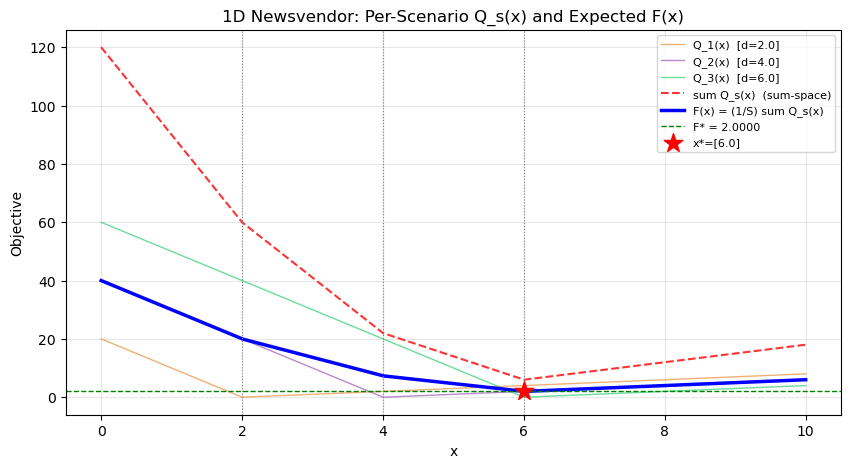

Solving Extensive Form ...
  EF optimal: F(x*)=2.000000  x*=6.000000
  EF vs closed-form F*: diff=0.00e+00  OK
Building scenario models ...
  3 scenarios built.  First-stage dim = 1
Building BaseBundle + MSBundle ...
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 30
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 30
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 30
  Done.
Initial nodes (2): [0.0, 10.0]
Initial ground-truth F(x) at nodes:
  x=  0.0000  F_true= 40.000000  F_solver= 40.000000
  x= 10.0000  F_true=  6.000000  F_solver=  6.000000

--- Running simplex loop (target=20 nodes) ---
Discarded solution info

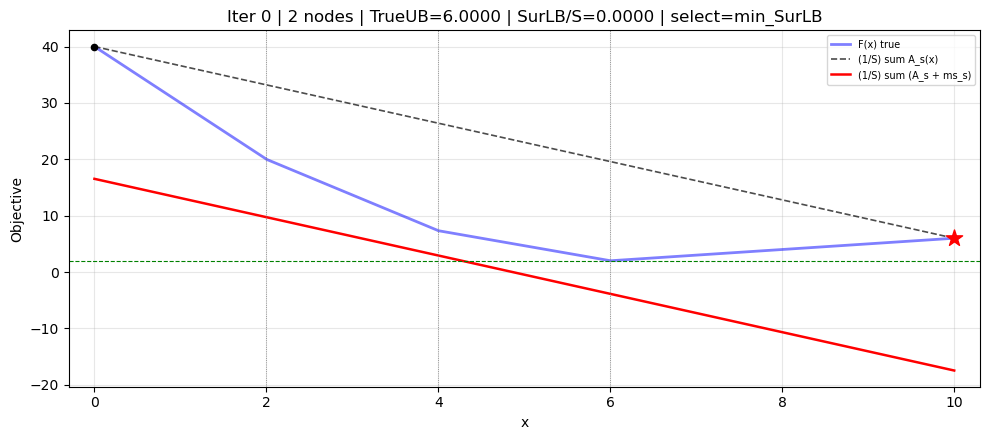

         -> split [0.0000, 10.0000]  SurLB=0.0000  SurLB/S=0.0000
[Iter   1] nodes=   3  TrueUB=  6.000000  TrueGap=4.0000e+00  SurLB/S=  2.000000  (select=min_SurLB)


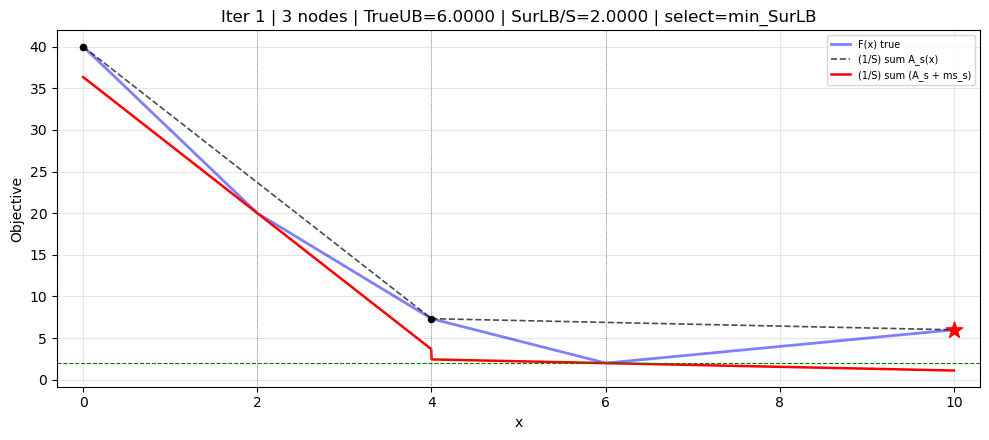

         -> split [4.0000, 10.0000]  SurLB=6.0000  SurLB/S=2.0000
[Iter   2] nodes=   4  TrueUB=  2.000000  TrueGap=0.0000e+00  SurLB/S=  2.000000  (select=min_SurLB)


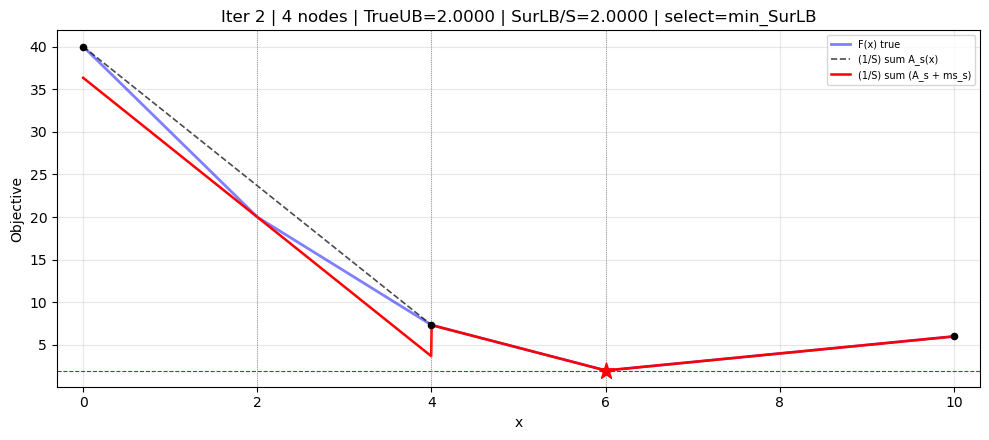

  STOP: true gap converged.

--- Done in 1.57s, 4 nodes ---
  True F*:         2.000000  at x* = [6.0]
  TrueUB (best):   2.000000
  TrueAbsGap:      0.000000e+00
  TrueRelGap:      0.000000e+00
  ✓ True optimum FOUND.
  SurLB/S:         2.000000
  Final nodes:     [0.0, 4.0, 6.0, 10.0]


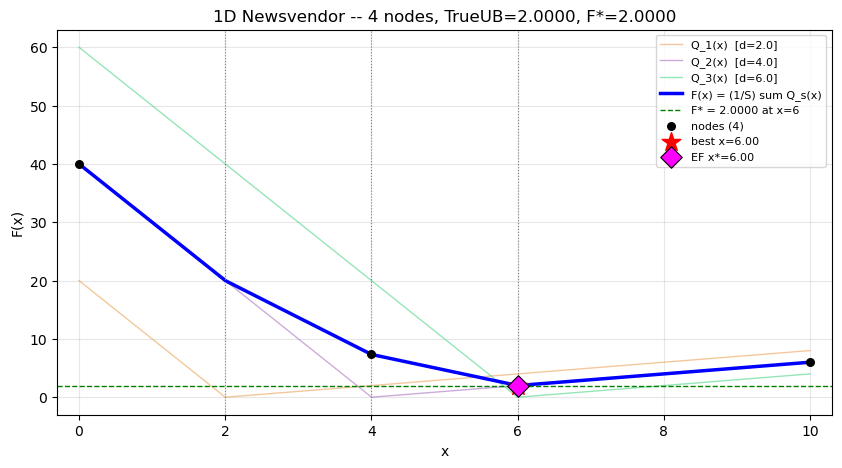

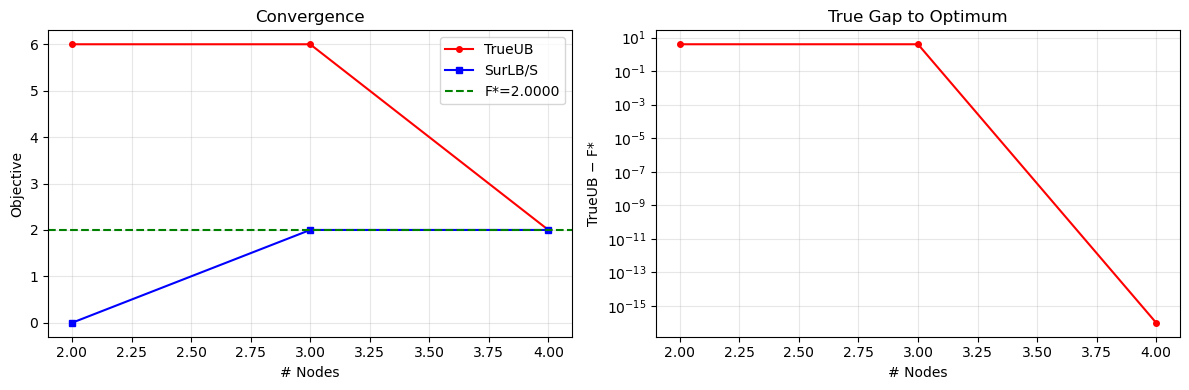

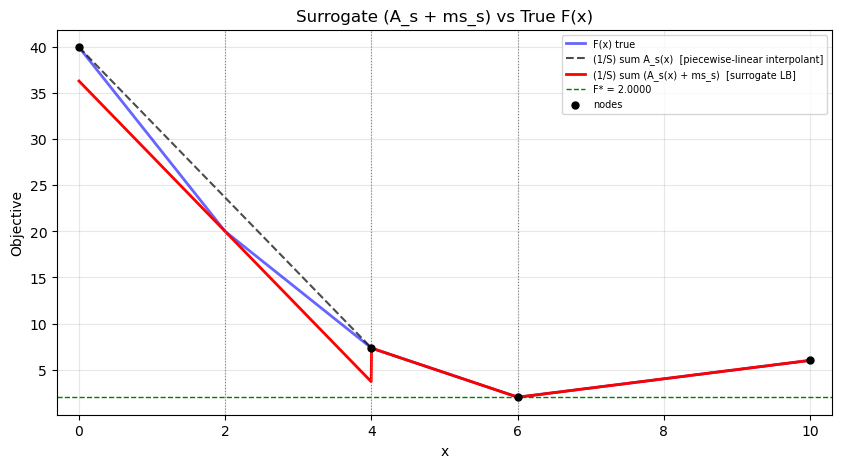

Per-interval ms values (last iteration):
  [0.0000, 4.0000]  ms = ['-11.0000', '0.0000', '0.0000']
  [4.0000, 6.0000]  ms = ['0.0000', '0.0000', '0.0000']
  [6.0000, 10.0000]  ms = ['0.0000', '0.0000', '0.0000']


In [8]:
"""
run_newsvendor_1d_case.py  --  Notebook-ready version.

Copy-paste this into a Jupyter notebook and run all cells.
Works in a single cell or split at the "# %%" markers.

Make sure the notebook's working directory is set to the pid_simplex_fv folder:
    import os; os.chdir(r"C:/Users/Administrator/OneDrive/Desktop/workspace2026/219_simplex_fv/pid_simplex_fv")
"""

# %%  ======= Setup & imports =================================================
import os, sys, csv, io, math
from pathlib import Path
from time import perf_counter
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt

# Ensure the script directory is on the path so local imports work
script_dir = Path(r"C:\Users\Administrator\OneDrive\Desktop\workspace2026\219_simplex_fv\pid_simplex_fv")
os.chdir(script_dir)

if str(script_dir) not in sys.path:
    sys.path.insert(0, str(script_dir))

np.random.seed(42)

# %%  ======= Problem parameters ==============================================

B = 10.0                              # budget / upper bound on x

PROBS = [1/3, 1/3, 1/3]              # equal scenario probabilities
C_SHORT = 10.0                        # shortage cost
C_HOLD  =  1.0                        # holding cost
DEMANDS = [2.0, 4.0, 6.0]            # scenario demands
SCENARIO_NAMES = ["lo", "mid", "hi"]

# Simplex run parameters  (edit these)
TARGET_NODES = 20
GAP_STOP_TOL = 1e-4
TIME_LIMIT   = None                   # None = unlimited

# Solver options (pure LP — no MIPGap needed)
UB_SOLVER_OPTS = {}
LB_SOLVER_OPTS = {"TimeLimit": 30}

# %%  ======= Ground truth ====================================================

def Q_scenario(x, d_s):
    """Single-scenario recourse cost."""
    return C_SHORT * max(d_s - x, 0.0) + C_HOLD * max(x - d_s, 0.0)

def F_true(x):
    """Expected recourse: (1/S) * sum_s Q_s(x)."""
    return sum(Q_scenario(x, d) for d in DEMANDS) / len(DEMANDS)

def compute_true_optimum():
    cands = sorted(set([0.0, B] + [max(0.0, min(B, d)) for d in DEMANDS]))
    f_vals = [(x, F_true(x)) for x in cands]
    F_star = min(fv for _, fv in f_vals)
    tol = 1e-12 * (abs(F_star) + 1.0)
    x_star_set = sorted(x for x, fv in f_vals if abs(fv - F_star) <= tol)
    return F_star, x_star_set, cands

F_star, x_star_set, cand_pts = compute_true_optimum()
print(f"TRUE OPTIMUM:  F* = {F_star:.6f}  at x* = {x_star_set}")
print(f"  Candidates: {cand_pts}")
print(f"  F values:   {[f'{F_true(c):.4f}' for c in cand_pts]}")

# %%  ======= Plot ground truth ================================================

xs_plot = np.linspace(0, B, 2000)
ys_plot = np.array([F_true(x) for x in xs_plot])

# Per-scenario Q_s(x) curves
qs_plot = {s: np.array([Q_scenario(x, DEMANDS[s]) for x in xs_plot]) for s in range(len(DEMANDS))}
qs_total = sum(qs_plot[s] for s in range(len(DEMANDS)))   # unweighted sum

scene_colors = ["#E8913A", "#9B59B6", "#2ECC71"]  # orange, purple, green

plt.figure(figsize=(10, 5))
for s in range(len(DEMANDS)):
    plt.plot(xs_plot, qs_plot[s], color=scene_colors[s], lw=1, alpha=0.7,
             label=f"Q_{s+1}(x)  [d={DEMANDS[s]}]")
plt.plot(xs_plot, qs_total, "r--", lw=1.5, alpha=0.8, label="sum Q_s(x)  (sum-space)")
plt.plot(xs_plot, ys_plot, "b-", lw=2.5, label="F(x) = (1/S) sum Q_s(x)")
plt.axhline(F_star, color="green", ls="--", lw=1, label=f"F* = {F_star:.4f}")
for d in DEMANDS:
    plt.axvline(d, color="gray", ls=":", lw=0.8)
plt.scatter(x_star_set, [F_star]*len(x_star_set), marker="*", c="red", s=200, zorder=5, label=f"x*={x_star_set}")
plt.xlabel("x"); plt.ylabel("Objective")
plt.title("1D Newsvendor: Per-Scenario Q_s(x) and Expected F(x)")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()

# %%  ======= Solve Extensive Form (EF) =======================================

def solve_ef_newsvendor_1d():
    """Solve the extensive form (shared x, scenario-specific u/v)."""
    ef = pyo.ConcreteModel(name="newsvendor1d_EF")
    SCENS = list(range(len(DEMANDS)))
    ef.x = pyo.Var(within=pyo.NonNegativeReals, bounds=(0, B))
    @ef.Constraint()
    def budget(ef): return ef.x <= B
    ef.u = pyo.Var(SCENS, within=pyo.NonNegativeReals)
    ef.v = pyo.Var(SCENS, within=pyo.NonNegativeReals)
    @ef.Constraint(SCENS)
    def demand_balance(ef, s): return ef.x + ef.u[s] - ef.v[s] == DEMANDS[s]
    ef.obj = pyo.Objective(
        expr=sum(PROBS[s]*(C_SHORT*ef.u[s]+C_HOLD*ef.v[s]) for s in SCENS),
        sense=pyo.minimize)
    for name in ("gurobi", "ipopt", "glpk"):
        slv = pyo.SolverFactory(name)
        if slv.available():
            res = slv.solve(ef, tee=False)
            if (res.solver.status == pyo.SolverStatus.ok and
                res.solver.termination_condition in
                    (pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal)):
                return pyo.value(ef.obj), pyo.value(ef.x)
    return None, None

print("Solving Extensive Form ...")
ef_obj, ef_x = solve_ef_newsvendor_1d()
if ef_obj is not None:
    print(f"  EF optimal: F(x*)={ef_obj:.6f}  x*={ef_x:.6f}")
    ef_diff = abs(ef_obj - F_star)
    print(f"  EF vs closed-form F*: diff={ef_diff:.2e}  {'OK' if ef_diff < 1e-6 else 'MISMATCH!'}")
else:
    print("  EF: no solver found.")
    ef_x = None

# %%  ======= Build Pyomo models ==============================================

def build_newsvendor_1d_models():
    model_list, first_vars_list = [], []
    for s, sname in enumerate(SCENARIO_NAMES):
        d_s = DEMANDS[s]
        m = pyo.ConcreteModel(name=f"newsvendor1d_{sname}")
        m.x = pyo.Var(within=pyo.NonNegativeReals, bounds=(0, B))
        @m.Constraint()
        def budget(m):
            return m.x <= B
        m.u = pyo.Var(within=pyo.NonNegativeReals)
        m.v = pyo.Var(within=pyo.NonNegativeReals)
        @m.Constraint()
        def demand_balance(m):
            return m.x + m.u - m.v == d_s
        obj_expression = C_SHORT * m.u + C_HOLD * m.v
        m.obj = pyo.Objective(expr=obj_expression, sense=pyo.minimize)
        m.obj_expr = pyo.Expression(expr=obj_expression)
        model_list.append(m)
        first_vars_list.append([m.x])
    return list(SCENARIO_NAMES), model_list, first_vars_list

print("Building scenario models ...")
scenario_names, model_list, first_vars_list = build_newsvendor_1d_models()
S = len(model_list)
print(f"  {S} scenarios built.  First-stage dim = {len(first_vars_list[0])}")

# %%  ======= Build solver bundles =============================================

print("Building BaseBundle + MSBundle ...")
from bundles import BaseBundle, MSBundle

base_bundles = [BaseBundle(m, UB_SOLVER_OPTS) for m in model_list]
ms_bundles = [
    MSBundle(m, fv, LB_SOLVER_OPTS, scenario_index=s)
    for s, (m, fv) in enumerate(zip(model_list, first_vars_list))
]
print("  Done.")

# %%  ======= 1D Simplex loop =================================================

from utils import evaluate_Q_at
from simplex_specialstart import ms_on_tetra_for_scene, solve_surrogate_lb_for_tet

# --- Initial nodes ---
nodes = [0.0, B]
nodes_tuples = [(x,) for x in nodes]

print(f"Initial nodes ({len(nodes)}): {nodes}")

# Evaluate Q at initial nodes
scen_values = [[None]*len(nodes) for _ in range(S)]
for i, xt in enumerate(nodes_tuples):
    for s in range(S):
        scen_values[s][i] = evaluate_Q_at(base_bundles[s], first_vars_list[s], xt)
f_true_at_node = [F_true(x) for x in nodes]

print("Initial ground-truth F(x) at nodes:")
for i, x in enumerate(nodes):
    solver_sum = sum(scen_values[s][i] for s in range(S)) / S
    print(f"  x={x:8.4f}  F_true={f_true_at_node[i]:10.6f}  F_solver={solver_sum:10.6f}")

# --- Histories ---
true_ub_hist, sur_lb_hist = [], []
node_count_hist, iter_time_hist = [], []
results_dir = script_dir / "results" / "newsvendor_1d_smoke"
results_dir.mkdir(parents=True, exist_ok=True)
csv_path = str(results_dir / "simplex_result.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    csv.writer(f).writerow(["Time(s)","#Nodes","TrueUB","TrueAbsGap","TrueRelGap","SurLB","SurGap"])

ms_cache = {}
t_start = perf_counter()
it = 0

print(f"\n--- Running simplex loop (target={TARGET_NODES} nodes) ---")

while len(nodes) < TARGET_NODES:
    N = len(nodes)
    true_ub = min(f_true_at_node)
    true_abs_gap = true_ub - F_star
    true_rel_gap = true_abs_gap / max(1e-12, abs(true_ub))

    # Build intervals
    intervals = []
    for k in range(N - 1):
        idxs = [k, k+1]
        verts = [nodes_tuples[k], nodes_tuples[k+1]]
        length = abs(nodes[k+1] - nodes[k])
        if length < 1e-14:
            continue
        fverts_per_scene = [[scen_values[s][j] for j in idxs] for s in range(S)]
        key_base = tuple(sorted(idxs))
        ms_scene, xms_scene, c_scene, cpts_scene = [], [], [], []
        for w in range(S):
            cache_key = (w, key_base)
            if cache_key in ms_cache:
                ms_val, new_pt_ms, c_val, c_pt = ms_cache[cache_key]
            else:
                ms_val, new_pt_ms, c_val, c_pt = ms_on_tetra_for_scene(
                    ms_bundles[w], verts, fverts_per_scene[w])
                ms_cache[cache_key] = (ms_val, new_pt_ms, c_val, c_pt)
            ms_scene.append(ms_val); xms_scene.append(new_pt_ms)
            c_scene.append(c_val);   cpts_scene.append(c_pt)

        ms_total = float(np.sum(ms_scene))
        fverts_sum = [sum(fverts_per_scene[s][j] for s in range(S)) for j in range(2)]
        sur_ub_int = float(max(fverts_sum)) + ms_total
        sur_lb_int = solve_surrogate_lb_for_tet(fverts_per_scene, ms_scene, c_scene)
        best_scene = int(np.argmin(ms_scene))
        intervals.append({
            "verts": verts, "SurLB": sur_lb_int, "SurUB": sur_ub_int,
            "xms_per_scene": xms_scene, "c_point_per_scene": cpts_scene,
            "x_ms_best_scene": xms_scene[best_scene], "fverts_sum": fverts_sum,
            "ms_per_scene": list(ms_scene),
            "fverts_per_scene": [list(row) for row in fverts_per_scene],
        })

    if not intervals:
        print("  No intervals — stopping."); break

    # Diagnostic (iter 0 only)
    if it == 0 and intervals:
        rec0 = intervals[0]
        print("[DIAG] interval0 fverts_sum=", rec0["fverts_sum"],
              "min(sum)=", min(rec0["fverts_sum"]),
              "min(exp)=", min(rec0["fverts_sum"])/S,
              "SurLB=", rec0["SurLB"], "SurLB/S=", rec0["SurLB"]/S)

    sur_lb_global = min(r["SurLB"] for r in intervals)

    # Record
    cum_time = perf_counter() - t_start
    true_ub_hist.append(true_ub); sur_lb_hist.append(sur_lb_global/S)
    node_count_hist.append(N); iter_time_hist.append(cum_time)
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow([f"{cum_time:.3f}", N, f"{true_ub:.9f}",
            f"{true_abs_gap:.6e}", f"{true_rel_gap:.6e}",
            f"{sur_lb_global/S:.9f}", f"{true_ub - sur_lb_global/S:.6e}"])

    print(f"[Iter {it:3d}] nodes={N:4d}  TrueUB={true_ub:10.6f}  "
          f"TrueGap={true_abs_gap:.4e}  SurLB/S={sur_lb_global/S:10.6f}  "
          f"(select=min_SurLB)")

    # --- Per-iteration plot: F(x) vs surrogate ---
    xs_it = np.linspace(0, B, 2000)
    ys_As   = np.full_like(xs_it, np.nan)
    ys_AsMs = np.full_like(xs_it, np.nan)
    for rec in intervals:
        a_ = rec["verts"][0][0]; b_ = rec["verts"][1][0]
        mask = (xs_it >= a_) & (xs_it <= b_)
        xs_seg = xs_it[mask]
        if len(xs_seg) == 0: continue
        t_ = (xs_seg - a_) / max(b_ - a_, 1e-15)
        as_seg = np.zeros_like(xs_seg)
        sm_seg = np.zeros_like(xs_seg)
        for s_ in range(S):
            As_x = rec["fverts_per_scene"][s_][0]*(1-t_) + rec["fverts_per_scene"][s_][1]*t_
            as_seg += As_x
            sm_seg += As_x + rec["ms_per_scene"][s_]
        ys_As[mask]   = as_seg / S
        ys_AsMs[mask] = sm_seg / S

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(xs_plot, ys_plot, "b-", lw=2, alpha=0.5, label="F(x) true")
    ax.plot(xs_it, ys_As,  "k--", lw=1.2, alpha=0.7, label="(1/S) sum A_s(x)")
    ax.plot(xs_it, ys_AsMs, "r-", lw=1.8, label="(1/S) sum (A_s + ms_s)")
    ax.axhline(F_star, color="green", ls="--", lw=0.8)
    for d in DEMANDS:
        ax.axvline(d, color="gray", ls=":", lw=0.6)
    ax.scatter(nodes, f_true_at_node, c="black", s=20, zorder=4)
    best_i_ = int(np.argmin(f_true_at_node))
    ax.scatter([nodes[best_i_]], [f_true_at_node[best_i_]], marker="*",
               c="red", s=150, zorder=5)
    ax.set_xlim(-0.3, B+0.3)
    ax.set_xlabel("x"); ax.set_ylabel("Objective")
    ax.set_title(f"Iter {it} | {N} nodes | TrueUB={true_ub:.4f} | "
                 f"SurLB/S={sur_lb_global/S:.4f} | select=min_SurLB")
    ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # Stop check
    if GAP_STOP_TOL and true_rel_gap <= GAP_STOP_TOL:
        print(f"  STOP: true gap converged."); break
    if TIME_LIMIT and (perf_counter() - t_start) >= TIME_LIMIT:
        print(f"  STOP: time limit."); break

    # Select interval to split (LOWEST surrogate LB)
    valid_ints = [r for r in intervals if math.isfinite(r["SurLB"])]
    if valid_ints:
        sel = min(valid_ints, key=lambda r: r["SurLB"])
    else:
        # Fallback: widest interval
        sel = max(intervals, key=lambda r: abs(r["verts"][1][0] - r["verts"][0][0]))
    sel_interval = (sel["verts"][0][0], sel["verts"][1][0])
    print(f"         -> split [{sel_interval[0]:.4f}, {sel_interval[1]:.4f}]  "
          f"SurLB={sel['SurLB']:.4f}  SurLB/S={sel['SurLB']/S:.4f}")

    # Pick candidate point
    cand_pt = sel["x_ms_best_scene"]
    if cand_pt is None:
        for cp in sel["c_point_per_scene"]:
            if cp is not None: cand_pt = cp; break
    if cand_pt is None:
        cand_pt = (0.5*(sel["verts"][0][0] + sel["verts"][1][0]),)
    new_x = max(0.0, min(B, float(cand_pt[0])))

    # Collision check
    if min(abs(new_x - n) for n in nodes) < 1e-12:
        new_x = 0.5*(sel["verts"][0][0] + sel["verts"][1][0])
        if min(abs(new_x - n) for n in nodes) < 1e-12:
            print(f"  Collision — stopping."); break

    # Insert
    insert_pos = sum(1 for n in nodes if n < new_x)
    nodes.insert(insert_pos, new_x)
    nodes_tuples.insert(insert_pos, (new_x,))
    for s in range(S):
        scen_values[s].insert(insert_pos,
            evaluate_Q_at(base_bundles[s], first_vars_list[s], (new_x,)))
    f_true_at_node.insert(insert_pos, F_true(new_x))
    ms_cache.clear()
    it += 1

dt_run = perf_counter() - t_start
print(f"\n--- Done in {dt_run:.2f}s, {len(nodes)} nodes ---")

# %%  ======= Results summary =================================================

final_true_ub = min(f_true_at_node)
final_true_abs = final_true_ub - F_star
final_true_rel = final_true_abs / max(1e-12, abs(final_true_ub))
final_sur_lb = sur_lb_hist[-1] if sur_lb_hist else float("nan")

print("=" * 60)
print(f"  True F*:         {F_star:.6f}  at x* = {x_star_set}")
print(f"  TrueUB (best):   {final_true_ub:.6f}")
print(f"  TrueAbsGap:      {final_true_abs:.6e}")
print(f"  TrueRelGap:      {final_true_rel:.6e}")
if final_true_abs < 1e-8:
    print(f"  ✓ True optimum FOUND.")
else:
    print(f"  ✗ True optimum NOT yet found.")
print(f"  SurLB/S:         {final_sur_lb:.6f}")
print(f"  Final nodes:     {nodes}")
print("=" * 60)

# %%  ======= Plot: final state ================================================

plt.figure(figsize=(10, 5))
for s in range(len(DEMANDS)):
    plt.plot(xs_plot, qs_plot[s], color=scene_colors[s], lw=1, alpha=0.5,
             label=f"Q_{s+1}(x)  [d={DEMANDS[s]}]")
plt.plot(xs_plot, ys_plot, "b-", lw=2.5, label="F(x) = (1/S) sum Q_s(x)")
plt.axhline(F_star, color="green", ls="--", lw=1, label=f"F* = {F_star:.4f} at x=6")
for d in DEMANDS:
    plt.axvline(d, color="gray", ls=":", lw=0.8)
plt.scatter(nodes, f_true_at_node, c="black", s=30, zorder=4, label=f"nodes ({len(nodes)})")
best_i = int(np.argmin(f_true_at_node))
plt.scatter([nodes[best_i]], [f_true_at_node[best_i]], marker="*", c="red",
            s=200, zorder=5, label=f"best x={nodes[best_i]:.2f}")
if ef_x is not None:
    plt.scatter([ef_x], [F_true(ef_x)], marker="D", c="magenta", s=120, zorder=6,
                edgecolors="black", linewidths=0.8, label=f"EF x*={ef_x:.2f}")
plt.xlim(-0.3, B+0.3)
plt.xlabel("x"); plt.ylabel("F(x)")
plt.title(f"1D Newsvendor -- {len(nodes)} nodes, TrueUB={final_true_ub:.4f}, F*={F_star:.4f}")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()

# %%  ======= Plot: convergence ================================================

if true_ub_hist:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(node_count_hist, true_ub_hist, "ro-", ms=4, label="TrueUB")
    ax1.plot(node_count_hist, sur_lb_hist, "bs-", ms=4, label="SurLB/S")
    ax1.axhline(F_star, color="green", ls="--", label=f"F*={F_star:.4f}")
    ax1.set_xlabel("# Nodes"); ax1.set_ylabel("Objective")
    ax1.set_title("Convergence"); ax1.legend(); ax1.grid(alpha=0.3)

    gaps = [ub - F_star for ub in true_ub_hist]
    ax2.semilogy(node_count_hist, [max(g, 1e-16) for g in gaps], "ro-", ms=4)
    ax2.set_xlabel("# Nodes"); ax2.set_ylabel("TrueUB − F*")
    ax2.set_title("True Gap to Optimum"); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# %%  ======= Plot: surrogate A_s+ms vs true F(x) =============================
# Build the piecewise surrogate from the LAST iteration's interval data.
# For each interval [a,b], scenario s:
#   A_s(x) = linear interp of Q_s(a), Q_s(b)
#   surrogate_s(x) = A_s(x) + ms_s
# Weighted surrogate: (1/S) * sum_s surrogate_s(x)

if intervals:
    # Fine x-grid for plotting
    xs_sur = np.linspace(0, B, 2000)
    ys_surrogate = np.full_like(xs_sur, np.nan)
    ys_As_only   = np.full_like(xs_sur, np.nan)   # just A_s (no ms)

    for rec in intervals:
        a = rec["verts"][0][0]
        b = rec["verts"][1][0]
        ms_list = rec["ms_per_scene"]
        fv_list = rec["fverts_per_scene"]  # fv_list[s] = [Q_s(a), Q_s(b)]

        mask = (xs_sur >= a) & (xs_sur <= b)
        xs_seg = xs_sur[mask]
        if len(xs_seg) == 0:
            continue

        # parameter t in [0,1] along the interval
        t = (xs_seg - a) / max(b - a, 1e-15)

        sur_seg = np.zeros_like(xs_seg)
        as_seg  = np.zeros_like(xs_seg)
        for s in range(S):
            As_x = fv_list[s][0] * (1 - t) + fv_list[s][1] * t  # linear interp
            as_seg  += As_x
            sur_seg += As_x + ms_list[s]

        ys_surrogate[mask] = sur_seg / S   # weighted
        ys_As_only[mask]   = as_seg / S

    plt.figure(figsize=(10, 5))
    plt.plot(xs_plot, ys_plot, "b-", lw=2, alpha=0.6, label="F(x) true")
    plt.plot(xs_sur, ys_As_only, "k--", lw=1.5, alpha=0.7,
             label="(1/S) sum A_s(x)  [piecewise-linear interpolant]")
    plt.plot(xs_sur, ys_surrogate, "r-", lw=2,
             label="(1/S) sum (A_s(x) + ms_s)  [surrogate LB]")
    plt.axhline(F_star, color="green", ls="--", lw=1, label=f"F* = {F_star:.4f}")
    for d in DEMANDS:
        plt.axvline(d, color="gray", ls=":", lw=0.8)
    plt.scatter(nodes, f_true_at_node, c="black", s=25, zorder=4, label="nodes")
    plt.xlim(-0.3, B+0.3)
    plt.xlabel("x"); plt.ylabel("Objective")
    plt.title("Surrogate (A_s + ms_s) vs True F(x)")
    plt.legend(fontsize=7, loc="upper right"); plt.grid(alpha=0.3)
    plt.show()

    # Also print ms values per interval for reference
    print("Per-interval ms values (last iteration):")
    for i, rec in enumerate(intervals):
        a, b = rec["verts"][0][0], rec["verts"][1][0]
        ms = rec["ms_per_scene"]
        print(f"  [{a:.4f}, {b:.4f}]  ms = {[f'{v:.4f}' for v in ms]}")